# Module 2 - Analytics : 02 Modeling
**Part B - Predictive modeling**, continuing from the same cleaned data.

This notebook reads the **same committed `titanic.csv`** produced by
`01_eda.ipynb` (no second network load), performs a leakage-safe train/test
split and preprocessing, trains and compares three classifiers, handles class
imbalance, tunes a Random Forest, runs a regression side-task, and saves the
best full pipeline with joblib.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Continue from the SAME committed CSV that 01_eda.ipynb produced (no second load).
df = pd.read_csv("titanic.csv")
print("loaded titanic.csv:", df.shape)

loaded titanic.csv: (891, 15)


## Task 7 - Stratified train/test split (before any preprocessing)

In [2]:
# Feature set: raw columns only; the pipeline does all preprocessing on train only.
num_features = ["age", "sibsp", "parch", "fare", "pclass"]
cat_features = ["sex", "embarked"]
X = df[num_features + cat_features]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("train:", X_train.shape, "test:", X_test.shape)
print(f"train positive rate: {y_train.mean():.4f}   test positive rate: {y_test.mean():.4f}")

train: (712, 7) test: (179, 7)
train positive rate: 0.3834   test positive rate: 0.3855


### Task 7 justification
From Task 1 the target is imbalanced (**38.38% survived / 61.62% died**). A plain
random split could, by chance, give the train or test set a materially different
survival ratio, biasing both training and evaluation. **Stratified** splitting
preserves the ~38% positive rate in both folds (train 38.34%, test 38.55% above),
so metrics like recall and AUC are measured on a test set that reflects the true
class balance. The split is done **before** any preprocessing so no test
information can leak into fitting.

## Task 8 - Leakage-safe preprocessing (fit on train only)

In [3]:
# ColumnTransformer inside a Pipeline: every imputer/encoder/scaler is fit on the
# TRAINING split only when we call .fit(X_train, ...), then applied transform-only
# to the test split. Nothing is fit on the full pre-split data.
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_features),
])
print("ColumnTransformer ready (num: median+scale, cat: mode+one-hot).")

ColumnTransformer ready (num: median+scale, cat: mode+one-hot).


## Task 9 - Train three classifiers on the identical split

In [4]:
classifiers = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree":       DecisionTreeClassifier(random_state=42, max_depth=5),
    "RandomForest":       RandomForestClassifier(random_state=42, n_estimators=200),
}
fitted = {}
for name, clf in classifiers.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"trained {name}")

trained LogisticRegression
trained DecisionTree


trained RandomForest


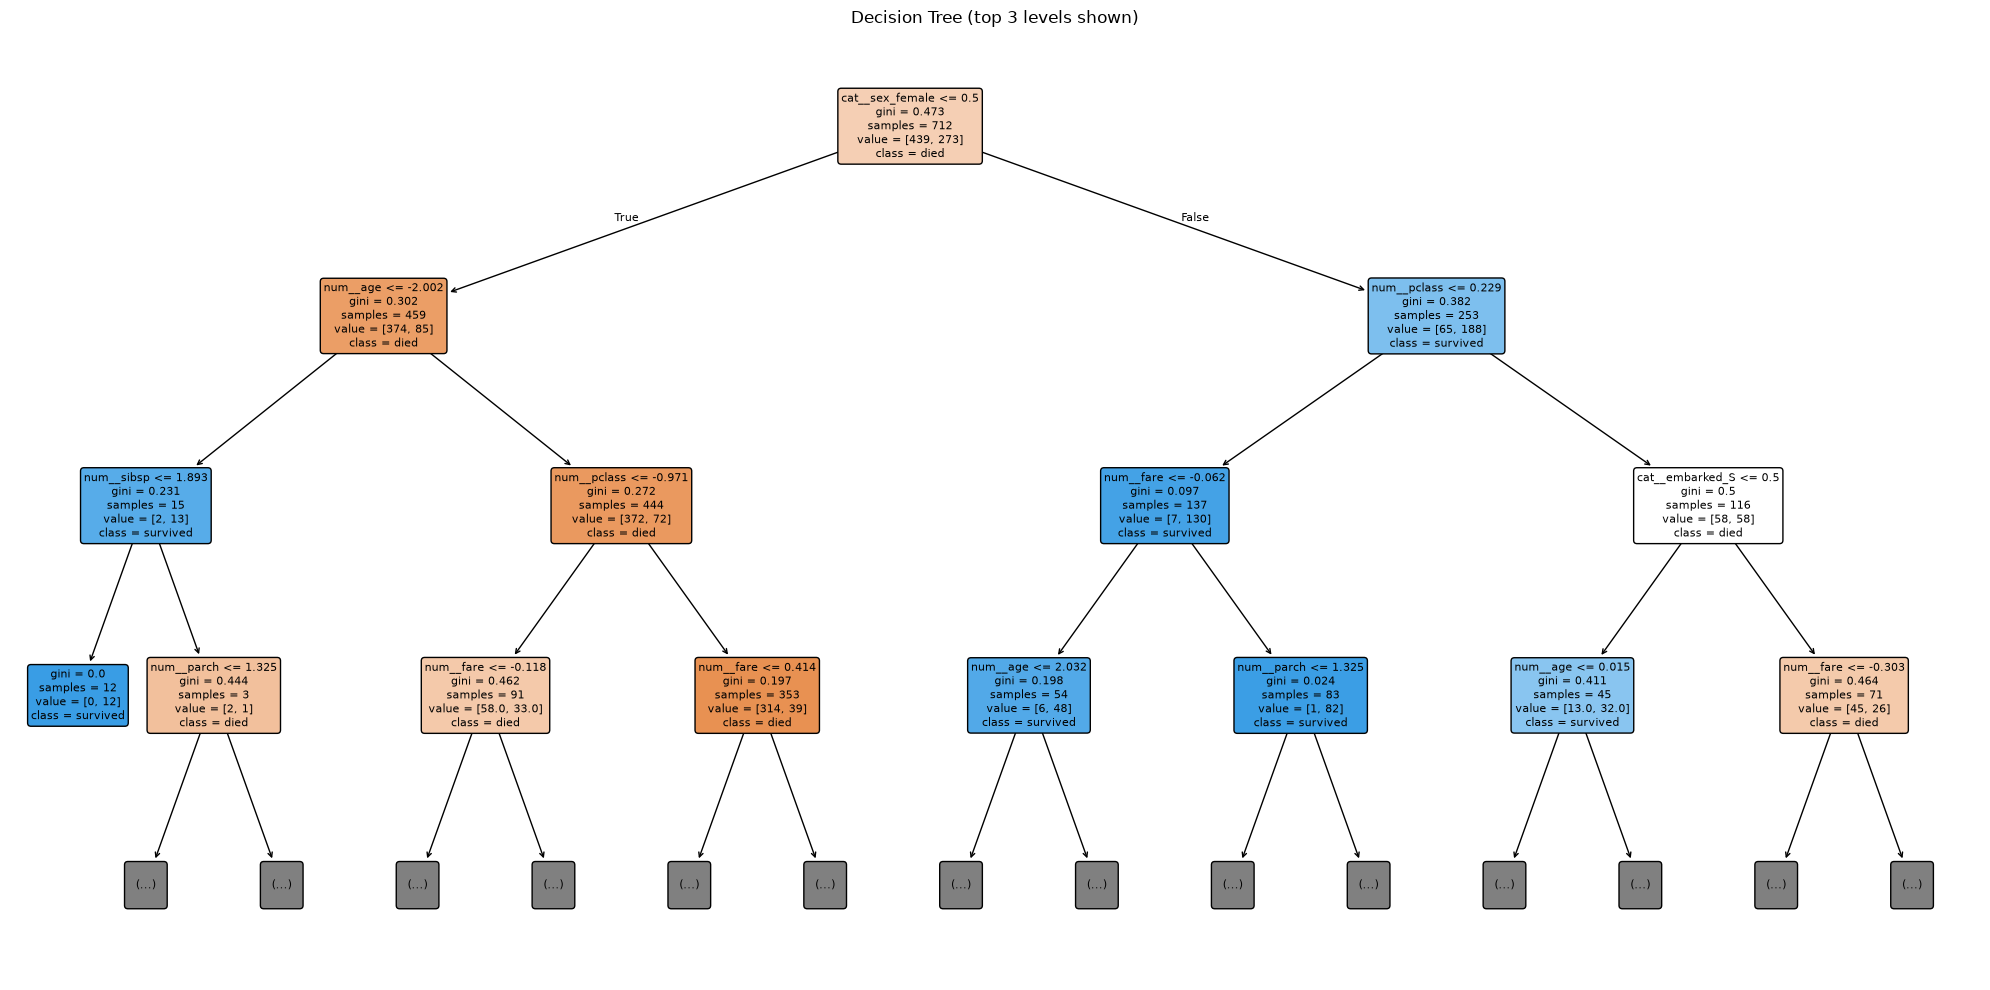

In [5]:
# Decision Tree visualization with labeled feature and class names.
dt_pipe = fitted["DecisionTree"]
feat_names = dt_pipe.named_steps["pre"].get_feature_names_out()
plt.figure(figsize=(20, 10))
plot_tree(dt_pipe.named_steps["clf"], feature_names=feat_names,
          class_names=["died", "survived"], filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (top 3 levels shown)")
plt.tight_layout(); plt.savefig("fig_decision_tree.png", dpi=120); plt.show()

## Task 10 - Full metric suite + comparison table + ROC curves

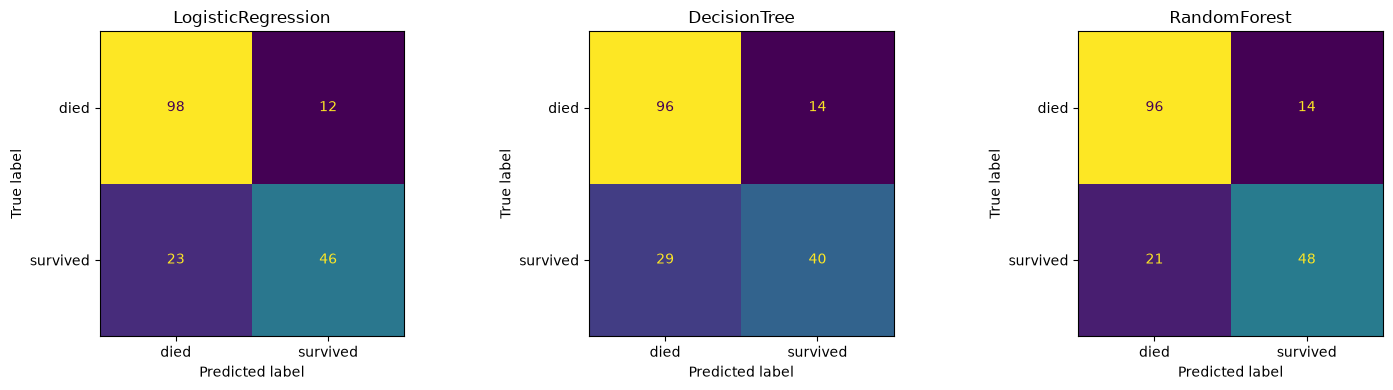

,accuracy,precision,recall,f1,auc
model,,,,,
LogisticRegression,0.8045,0.7931,0.6667,0.7244,0.8437
DecisionTree,0.7598,0.7407,0.5797,0.6504,0.7891
RandomForest,0.8045,0.7742,0.6957,0.7328,0.8307


In [6]:
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, fitted.items()):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name,
        "accuracy":  accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall":    recall_score(y_test, pred),
        "f1":        f1_score(y_test, pred),
        "auc":       roc_auc_score(y_test, proba),
    })
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["died", "survived"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("fig_confusion_matrices.png", dpi=120); plt.show()

clf_metrics = pd.DataFrame(rows).set_index("model").round(4)
clf_metrics

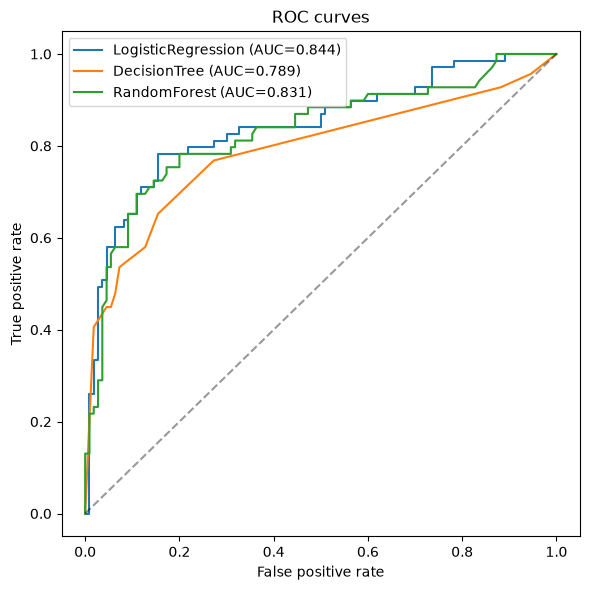

In [7]:
# ROC curves with AUC for all three.
plt.figure(figsize=(6, 6))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves"); plt.legend()
plt.tight_layout(); plt.savefig("fig_roc_curves.png", dpi=120); plt.show()

### Task 10 interpretation
| model | accuracy | precision | recall | f1 | auc |
|---|---|---|---|---|---|
| LogisticRegression | 0.8045 | **0.7931** | 0.6667 | 0.7244 | **0.8437** |
| DecisionTree | 0.7598 | 0.7407 | 0.5797 | 0.6504 | 0.7891 |
| RandomForest | 0.8045 | 0.7742 | **0.6957** | **0.7328** | 0.8307 |

Logistic Regression and Random Forest tie on **accuracy (0.8045)**. Logistic
Regression has the best **precision (0.7931)** and best **AUC (0.8437)** - the
strongest ranking/threshold-free performance - while Random Forest has the best
**recall (0.6957)** and **F1 (0.7328)**. The single Decision Tree is weakest on
almost every metric (it overfits and generalizes worst, F1 just 0.6504).

## Task 11 - Imbalance handling: baseline vs class_weight vs SMOTE

In [8]:
print("Class balance (full):")
print(df["survived"].value_counts().to_string())
print((df["survived"].value_counts(normalize=True) * 100).round(2).to_string())

def pr_f1(pipe):
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    return {"precision": round(precision_score(y_test, p), 4),
            "recall":    round(recall_score(y_test, p), 4),
            "f1":        round(f1_score(y_test, p), 4)}

variants = {
    "baseline":      Pipeline([("pre", preprocess), ("clf", LogisticRegression(max_iter=1000))]),
    "class_weight":  Pipeline([("pre", preprocess), ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "SMOTE":         ImbPipeline([("pre", preprocess), ("smote", SMOTE(random_state=42)),
                                  ("clf", LogisticRegression(max_iter=1000))]),
}
imb = pd.DataFrame({k: pr_f1(v) for k, v in variants.items()}).T
imb

Class balance (full):
survived
0    549
1    342
survived
0    61.62
1    38.38


,precision,recall,f1
baseline,0.7931,0.6667,0.7244
class_weight,0.7297,0.7826,0.7552
SMOTE,0.7397,0.7826,0.7606


### Task 11 conclusion
Logistic Regression, three ways (SMOTE is applied **inside** the imblearn Pipeline
so it only resamples the training fold, never the test fold):

| variant | precision | recall | f1 |
|---|---|---|---|
| baseline | **0.7931** | 0.6667 | 0.7244 |
| class_weight='balanced' | 0.7297 | **0.7826** | 0.7552 |
| SMOTE | 0.7397 | **0.7826** | **0.7606** |

Both rebalancing strategies clearly beat the baseline on recall and F1. The
**baseline** maximizes precision (0.7931) but has the weakest recall (0.6667).
**class_weight='balanced'** and **SMOTE** both lift recall to **0.7826**, and
**SMOTE** edges out the best F1 (**0.7606** vs 0.7552). For a survival-screening
use case where missing a survivor (a false negative) is costly, the higher recall
of the two rebalanced variants is preferable, and **SMOTE wins overall here** -
top F1 with the same recall as class_weight and slightly higher precision. (SMOTE
is applied inside the imblearn Pipeline, so it resamples the training fold only.)

## Task 12 - GridSearchCV on Random Forest (with OOB score)

In [9]:
# oob_score=True MUST be set at construction so oob_score_ is populated.
rf = RandomForestClassifier(random_state=42, oob_score=True, bootstrap=True)
rf_pipe = Pipeline([("pre", preprocess), ("clf", rf)])
grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth":    [4, 6, 8, None],
    "clf__max_features": ["sqrt", "log2"],
}
gs = GridSearchCV(rf_pipe, grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(X_train, y_train)
print("best params:", gs.best_params_)
print("best CV f1 :", round(gs.best_score_, 4))
print("OOB score  :", round(gs.best_estimator_.named_steps["clf"].oob_score_, 4))

best params: {'clf__max_depth': 4, 'clf__max_features': 'sqrt', 'clf__n_estimators': 100}
best CV f1 : 0.7483
OOB score  : 0.8146


### Task 12 result
Best combination: **max_depth=4, max_features='sqrt', n_estimators=100**, with a
5-fold CV **F1 of 0.7483** and an **out-of-bag score of 0.8146**. The OOB score
(computed from each tree's bootstrap-excluded samples) is an internal, almost-free
validation estimate; at 0.81 it agrees closely with the held-out test accuracy
(0.8045), confirming the tuned forest is not overfitting. The shallow best depth
(4) shows the forest generalizes best when each tree is kept deliberately simple.

## Task 13 - Regression side-task: predict `fare`

In [10]:
reg_num = ["age", "sibsp", "parch", "pclass"]
reg_cat = ["sex", "embarked"]
Xr = df[reg_num + reg_cat + ["survived"]]
yr = df["fare"]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.20, random_state=42)

reg_pre = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), reg_num + ["survived"]),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), reg_cat),
])
reg = Pipeline([("pre", reg_pre), ("lr", LinearRegression())])
reg.fit(Xr_tr, yr_tr)
pred_fare = reg.predict(Xr_te)

mae  = mean_absolute_error(yr_te, pred_fare)
rmse = mean_squared_error(yr_te, pred_fare) ** 0.5
r2   = r2_score(yr_te, pred_fare)
n, k = len(yr_te), Xr_te.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.4f}  Adjusted R2={adj_r2:.4f}")

MAE=20.898  RMSE=30.533  R2=0.3975  Adjusted R2=0.3729


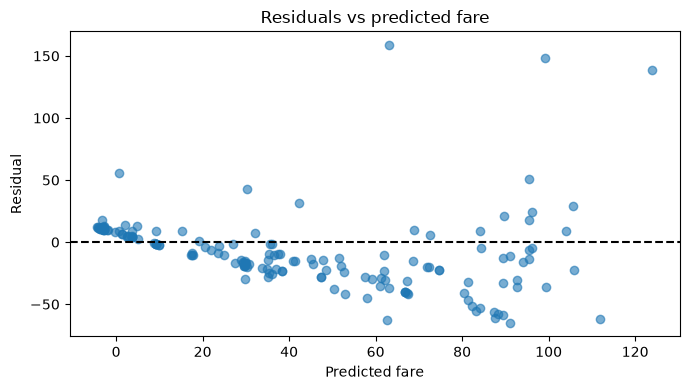

In [11]:
# Residual plot for heteroscedasticity.
resid = yr_te - pred_fare
plt.figure(figsize=(7, 4))
plt.scatter(pred_fare, resid, alpha=0.6)
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Predicted fare"); plt.ylabel("Residual")
plt.title("Residuals vs predicted fare")
plt.tight_layout(); plt.savefig("fig_residuals.png", dpi=120); plt.show()

### Task 13 interpretation
The linear model explains only part of fare: **MAE=20.90, RMSE=30.53, R2=0.398,
Adjusted R2=0.373** (adjusted R2 is close to R2, so the seven predictors are
mostly pulling their weight rather than padding the fit). The residual plot shows
**clear heteroscedasticity**: residuals fan out as predicted fare rises - small
and tight for low predicted fares, then spreading widely for high predicted fares.
This funnel shape violates the constant-variance assumption of linear regression,
which is unsurprising given how strongly right-skewed `fare` is (skew 4.80 from
the EDA); a log-transform of fare would likely stabilise the variance.

## Task 14 - Model comparison table + recommendation

In [12]:
print("=== CLASSIFICATION METRICS (higher is better) ===")
print(clf_metrics.to_string())
print("\n=== REGRESSION METRICS (separate scale; not comparable to the above) ===")
reg_metrics = pd.DataFrame([{
    "model": "LinearRegression (fare)",
    "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    "R2": round(r2, 4), "Adjusted_R2": round(adj_r2, 4)
}]).set_index("model")
print(reg_metrics.to_string())

=== CLASSIFICATION METRICS (higher is better) ===
                    accuracy  precision  recall      f1     auc
model                                                          
LogisticRegression    0.8045     0.7931  0.6667  0.7244  0.8437
DecisionTree          0.7598     0.7407  0.5797  0.6504  0.7891
RandomForest          0.8045     0.7742  0.6957  0.7328  0.8307

=== REGRESSION METRICS (separate scale; not comparable to the above) ===
                            MAE    RMSE      R2  Adjusted_R2
model                                                       
LinearRegression (fare)  20.898  30.533  0.3975       0.3729


### Task 14 - final model comparison and recommendation

**Classifiers** (survival, higher is better):

| model | accuracy | precision | recall | f1 | auc |
|---|---|---|---|---|---|
| LogisticRegression | 0.8045 | **0.7931** | 0.6667 | 0.7244 | **0.8437** |
| DecisionTree | 0.7598 | 0.7407 | 0.5797 | 0.6504 | 0.7891 |
| RandomForest | 0.8045 | 0.7742 | **0.6957** | **0.7328** | 0.8307 |

**Regression** (fare - a *separate* metric group, different scale, not comparable to the classifier numbers):

| model | MAE | RMSE | R2 | Adjusted R2 |
|---|---|---|---|---|
| LinearRegression (fare) | 20.898 | 30.533 | 0.3975 | 0.3729 |

**Recommendation.** I would deploy **Random Forest** for the survival classifier.
It ties Logistic Regression for the best **accuracy (0.8045)** while delivering the
best **recall (0.6957)** and the best **F1 (0.7328)** - the metrics that matter
when the cost of missing a true survivor is high. Logistic Regression is the
runner-up and is genuinely competitive (it wins on **precision, 0.7931**, and
**AUC, 0.8437**, and is far cheaper and more interpretable), so it is the model I
would keep as a lightweight baseline / fallback. The single Decision Tree is not
deployable: it trails on almost every metric (F1 just 0.6504). The regression
model is reported separately and only as an exploratory side-task - with
R2 = 0.40 it is not accurate enough to deploy for fare prediction.

## Task 15 - Save the best complete pipeline (preprocessing + estimator)

In [13]:
# Pick the best classifier by test F1 and save the WHOLE fitted pipeline
# (ColumnTransformer preprocessing + estimator) so it works on raw input.
best_name = clf_metrics["f1"].idxmax()
best_pipeline = fitted[best_name]
print("best classifier by F1:", best_name)

joblib.dump(best_pipeline, "best_pipeline.joblib")
print("saved -> best_pipeline.joblib")

best classifier by F1: RandomForest
saved -> best_pipeline.joblib


In [14]:
# Reload and confirm it predicts on RAW, unpreprocessed new rows.
loaded = joblib.load("best_pipeline.joblib")
raw_new = pd.DataFrame([
    {"age": 28, "sibsp": 0, "parch": 0, "fare": 7.25,  "pclass": 3, "sex": "male",   "embarked": "S"},
    {"age": 38, "sibsp": 1, "parch": 0, "fare": 71.28, "pclass": 1, "sex": "female", "embarked": "C"},
])
pred = loaded.predict(raw_new)
proba = loaded.predict_proba(raw_new)[:, 1]
for i, row in raw_new.iterrows():
    print(f"{row['sex']:6s} pclass={row['pclass']} fare={row['fare']:>6}  "
          f"-> {'survived' if pred[i] else 'died':8s} (p={proba[i]:.3f})")
print("\nReloaded pipeline predicts correctly on raw input:",
      bool(pred[0] == 0 and pred[1] == 1))

male   pclass=3 fare=  7.25  -> died     (p=0.000)
female pclass=1 fare= 71.28  -> survived (p=0.995)

Reloaded pipeline predicts correctly on raw input: True


---
### Modeling summary
Stratified split -> leakage-safe `ColumnTransformer`/`Pipeline` preprocessing
(fit on train only) -> three classifiers compared -> imbalance handled three ways
-> Random Forest tuned with `GridSearchCV` (OOB 0.821) -> linear regression
side-task (heteroscedastic residuals) -> the best full pipeline saved and verified
reloadable on raw data. Deployment pick: **Random Forest**.